<a href="https://colab.research.google.com/github/Sobaka010/f-/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BF%D0%BE_%D1%82%D0%B5%D0%BC%D0%B5_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейная регрессия и основные библиотеки Python для анализа данных и научных вычислений

Это задание посвящено линейной регрессии. На примере прогнозирования уровня зарплаты от количества лет опыта работы Вы увидите, какая математика за этим стоит, а заодно познакомитесь с основными библиотеками Python, необходимыми для дальнейшего прохождения курса.

**Материалы**

- Лекции данного курса по линейным моделям и градиентному спуску
- [Документация](http://docs.scipy.org/doc/) по библиотекам NumPy и SciPy
- [Документация](http://matplotlib.org/) по библиотеке Matplotlib
- [Документация](http://pandas.pydata.org/pandas-docs/stable/tutorials.html) по библиотеке Pandas
- [Документация](http://stanford.edu/~mwaskom/software/seaborn/) по библиотеке Seaborn
- [Документация](http://scikit-learn.ru) по библиотеке Sklearn

## Задание 1. Первичный анализ данных c Pandas

В этом заданиии мы будем использовать данные [SOCR](http://wiki.stat.ucla.edu/socr/index.php/SOCR_Data_Dinov_020108_HeightsWeights) по росту и весу 25 тысяч подростков.

In [ ]:
!pip install numpy scipy pandas matplotlib scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

Считаем данные по уровню зарплаты в зависимости от количества лет опыта (*Salary_dataset.csv*, приложенный в задании) в объект Pandas DataFrame:

In [ ]:
df = pd.read_csv('Salary_dataset.csv', index_col=0)


[1] Выведите загруженный датасет и опеределите количество записей в нем

In [ ]:
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [ ]:
print(df.shape[0])
len(df)

30


30

[2] Постройте две гистограммы, чтобы оценить вид распределения данных для признаков *Salary* и *YearsExperience*. Количество интервалов при построении диаграммы сделайте равным 10. Диаграммы сделайте разного цвета. Для каждой гистограммы выведите заголовок и подписи осей. Легенду не выводите.

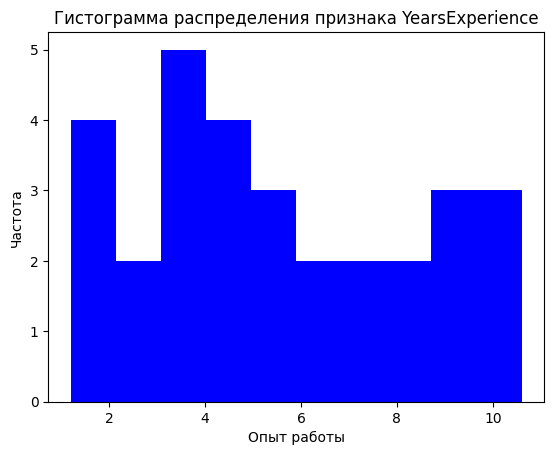

In [ ]:
df.plot(y = 'YearsExperience', kind='hist', color = 'blue', legend = False, title = 'Гистограмма распределения признака YearsExperience', xlabel = 'Опыт работы', ylabel = 'Частота');

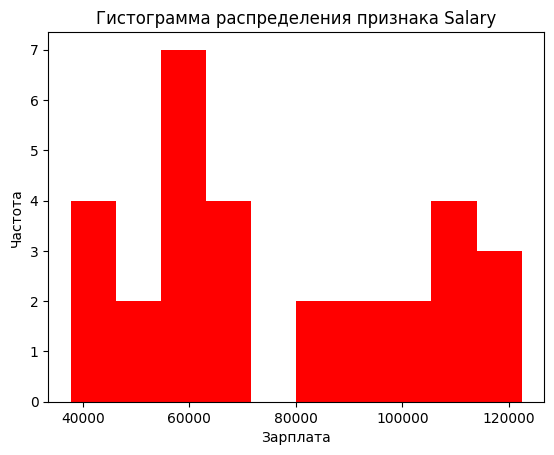

In [ ]:
df.plot(y = 'Salary', kind='hist', color = 'red', legend = False, title = 'Гистограмма распределения признака Salary', xlabel = 'Зарплата', ylabel = 'Частота');

**[3].** Постройте картинку, на которой будут отображены попарные зависимости признаков , 'Salary', 'YearsExperience'. Используйте метод *pairplot* библиотеки Seaborn.

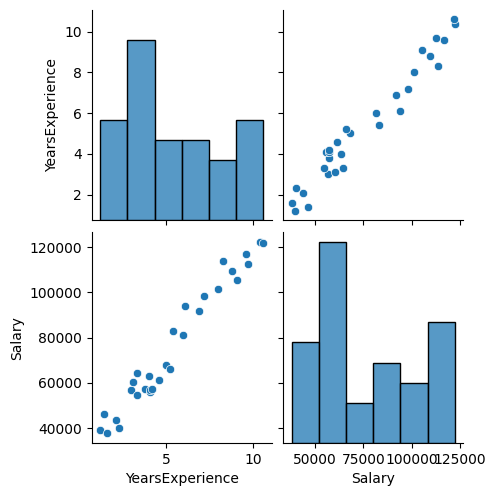

In [ ]:
sns.pairplot(df);

**[4]**. Создайте в DataFrame *df* новый признак *employee_category*, который будет иметь 3 значения:

**1** – если его опыт работы меньше 3 лет,

**2** - если опыт работы от 3 до 7 лет включительно,

**3** – в остальных случаях.

Выведите 10 последних записей датасета после изменения.

Постройте «ящики с усами» (boxplot), демонстрирующий зависимость велиичины зарплаты от категории опыта работы. Используйте метод *boxplot* библиотеки Seaborn и метод *apply* Pandas DataFrame. Подпишите ось *y* меткой «Размер зарплаты», ось *x* – меткой «Категория опытности сотрудника». Также сжелайте заголовок для всей диаграммы.

In [ ]:
def employee_category(level):
  if level < 3:
    return 1
  elif level >= 3 and level <= 7:
    return 2
  else:
    return 3

df['Характеристика'] = df['YearsExperience'].apply(employee_category)

In [ ]:
df.tail(10)

,YearsExperience,Salary,Характеристика
20,6.9,91739.0,2
21,7.2,98274.0,3
22,8.0,101303.0,3
23,8.3,113813.0,3
24,8.8,109432.0,3
25,9.1,105583.0,3
26,9.6,116970.0,3
27,9.7,112636.0,3
28,10.4,122392.0,3
29,10.6,121873.0,3


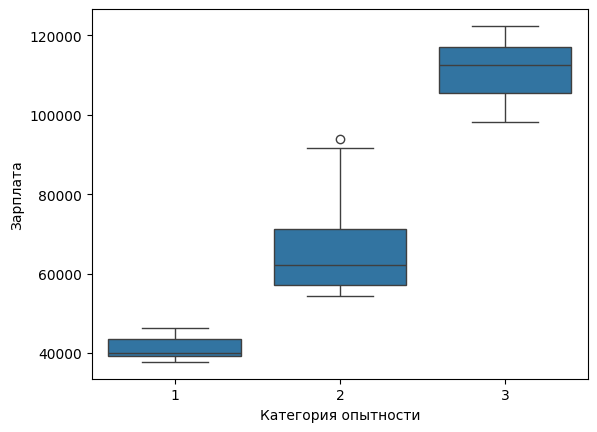

In [ ]:
ax = sns.boxplot(x='Характеристика',y = 'Salary',data=df)
ax.set(xlabel = 'Категория опытности',ylabel = 'Зарплата')
plt.show()

**[5].** Постройте диаграмму рассеяния зависимости зарплаты от количества лет опыта сотрудников, используя метод *plot* для Pandas DataFrame с аргументом *kind='scatter'*. Подпишите оси и  картинку.

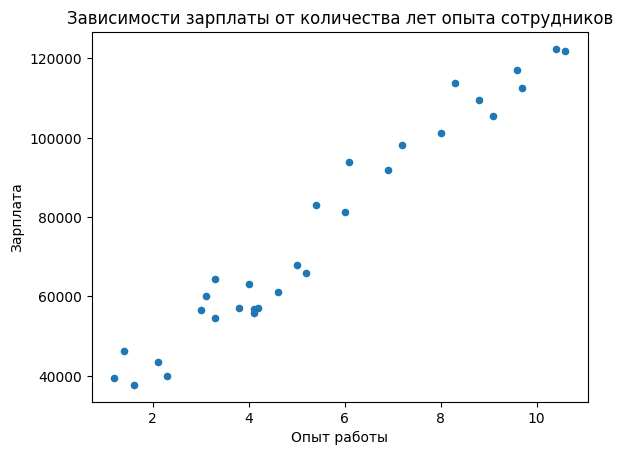

In [ ]:
df.plot(x ='YearsExperience', y ='Salary',kind='scatter', title = "Зависимости зарплаты от количества лет опыта сотрудников", xlabel = 'Опыт работы', ylabel = 'Зарплата');

## Задание 2. Минимизация квадратичной ошибки

В простейшей постановке задача прогноза значения вещественного признака по прочим признакам (задача восстановления регрессии) решается минимизацией квадратичной функции ошибки.

**[6].** Напишите функцию, которая по двум параметрам $w_0$ и $w_1$ вычисляет квадратичную ошибку приближения зависимости уровня зарплаты $y$ от опытности сотрудника $x$ прямой линией $y = w_0 + w_1 * x$:
$$error(w_0, w_1) = \sum_{i=1}^n {(y_i - (w_0 + w_1 * x_i))}^2 $$
Здесь $n$ – число наблюдений в наборе данных, $y_i$ и $x_i$ – зарплата и количество лет опыта $i$-ого человека в наборе данных.

In [ ]:
def error(w0, w1):
    z = df.Salary
    d = (w0 + w1 * df.YearsExperience)
    z = (z - d) ** 2
    return z.sum()

Итак, мы решаем задачу: как через облако точек, соответствующих наблюдениям в нашем наборе данных, в пространстве признаков "Salary" и "YearsExperience" провести прямую линию так, чтобы минимизировать функционал из п. 6. Для начала давайте отобразим хоть какие-то прямые и убедимся, что они плохо передают искомую зависимость.

**[7].** Проведите на графике из п. 5 Задания 1 две прямые, соответствующие значениям параметров ($w_0, w_1) = (20000, 5000)$ и ($w_0, w_1) = (50000, 16000)$. Используйте метод *plot* из *matplotlib.pyplot*, а также метод *linspace* библиотеки NumPy. Подпишите оси, график и сделайте легенду. Диапазоном значений по оси X сделайте промежуток [0; 12].

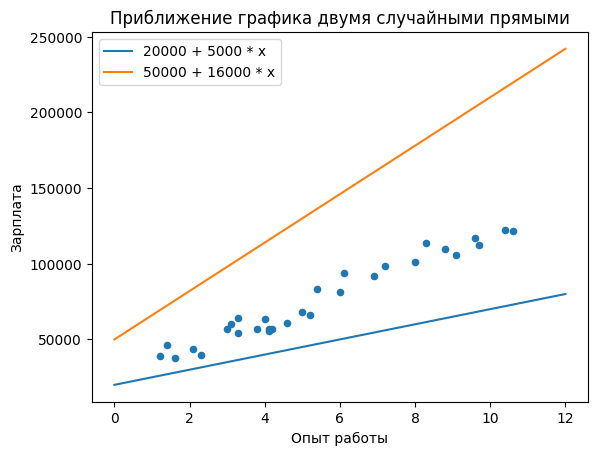

In [ ]:
df.plot(x ='YearsExperience', y ='Salary',kind='scatter', title = "Приближение графика двумя случайными прямыми", xlabel = 'Опыт работы', ylabel = 'Зарплата');
x = np.linspace(0, 12)
y1 = 20000 + 5000 * x
plt.plot(x, y1, label = '20000 + 5000 * x');
y2 = 50000 + 16000 * x
plt.plot(x, y2, label = '50000 + 16000 * x');
plt.legend(loc='best')
plt.show()

Минимизация квадратичной функции ошибки - относительная простая задача, поскольку функция выпуклая. Для такой задачи существует много методов оптимизации. Посмотрим, как функция ошибки зависит от одного параметра (наклон прямой), если второй параметр (свободный член) зафиксировать.

**[8].** Постройте график зависимости функции ошибки, посчитанной в п. 6, от параметра $w_1$ при $w_0$ = 30000 Подпишите оси и график. Диапазоном значений по оси X сделайте промежуток [1000; 15000].

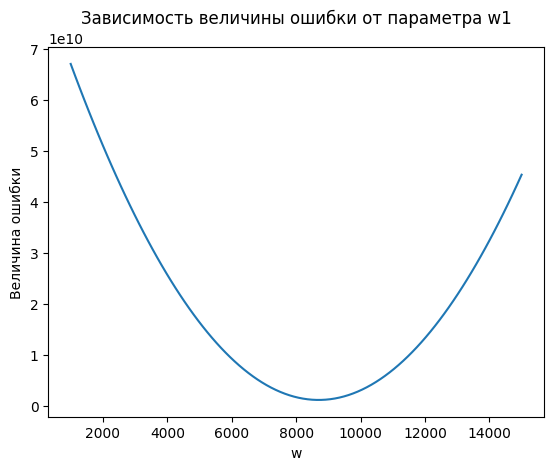

In [ ]:
w1 = np.linspace(1000,15000.5,100)
err = np.fromiter((error(30000, el) for el in w1), dtype=float)
plt.plot(w1,err)
plt.title(u'Зависимость величины ошибки от параметра w1')
plt.xlabel('w')
plt.ylabel(u'Величина ошибки')
plt.show()

Теперь методом оптимизации найдем "оптимальный" наклон прямой, приближающей зависимость роста от веса, при фиксированном коэффициенте $w_0 = 50$.

**[9].** С помощью метода *minimize_scalar* из *scipy.optimize* найдите минимум функции, определенной в п. 6, для значений параметра  $w_1$ в диапазоне [6000,12000]. Проведите на графике из п. 5 Задания 1 прямую, соответствующую значениям параметров ($w_0$, $w_1$) = (30000, $w_1\_opt$), где $w_1\_opt$ – найденное в п. 8 оптимальное значение параметра $w_1$ с точностью 0 знаков после запятой.

In [ ]:
from scipy.optimize import minimize_scalar

In [ ]:
def err_fixed_w0(w1):
    return error(30000, w1)

In [ ]:
w1_opt_res = minimize_scalar(err_fixed_w0, bounds=(6000, 12000))
w1_opt = w1_opt_res.x
w1_opt

np.float64(8698.037531006219)

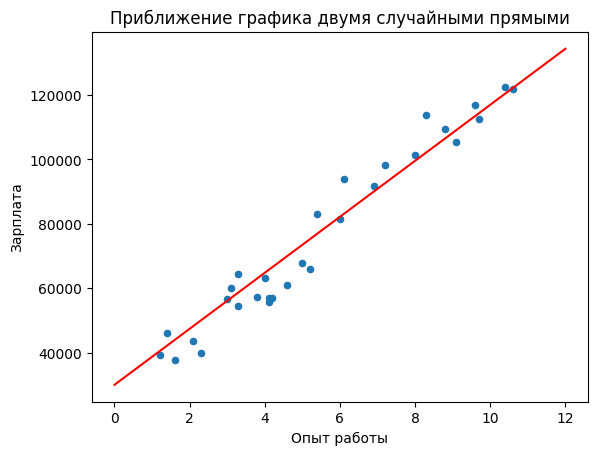

In [ ]:
df.plot(x ='YearsExperience', y ='Salary',kind='scatter', title = "Приближение графика двумя случайными прямыми", xlabel = 'Опыт работы', ylabel = 'Зарплата');
x = np.linspace(0, 12)
y_opt = 30000 + w1_opt * x
plt.plot(x, y_opt, 'r');


При анализе многомерных данных человек часто хочет получить интуитивное представление о природе данных с помощью визуализации. Увы, при числе признаков больше 3 такие картинки нарисовать невозможно. На практике для визуализации данных в 2D и 3D в данных выделаяют 2 или, соответственно, 3 главные компоненты и отображают данные на плоскости или в объеме.

Посмотрим, как в Python рисовать 3D картинки, на примере отображения функции $z(x,y) = sin(\sqrt{x^2+y^2})$ для значений $x$ и $y$ из интервала [-5,5] c шагом 0.25.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

Создаем объекты типа matplotlib.figure.Figure (рисунок) и  matplotlib.axes._subplots.Axes3DSubplot (ось).

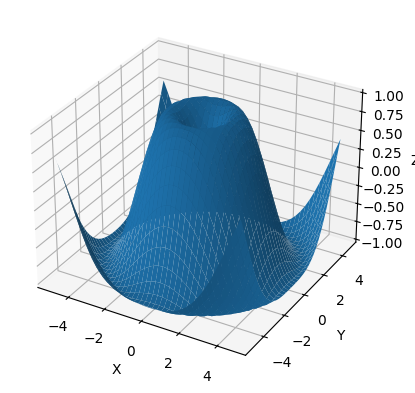

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d') # get current axis

# Создаем массивы NumPy с координатами точек по осям X и У.
# Используем метод meshgrid, при котором по векторам координат
# создается матрица координат. Задаем нужную функцию Z(x, y).
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Наконец, используем метод *plot_surface* объекта
# типа Axes3DSubplot. Также подписываем оси.
surf = ax.plot_surface(X, Y, Z)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

**[10].** Постройте 3D-график зависимости функции ошибки, посчитанной в п.6 от параметров $w_0$ и $w_1$. Подпишите ось $x$ меткой «Смещение (b)», ось $y$ – меткой «Наклон» (k), a ось $z$ – меткой «Ошибка». При построении графика параметр w1 изменяйте на промежутке от [1000;15000] с шагом 50, а пеараметр w0 изменяйте на промежутке от [10000;40000] с шагом 200.

In [ ]:
w1_space = np.arange(1000, 15000, 50)
w0_space = np.arange(10000, 40000, 200)
w0, w1 = np.meshgrid(w0_space, w1_space)
vec_err = np.vectorize(error)
Z = vec_err(w0, w1)

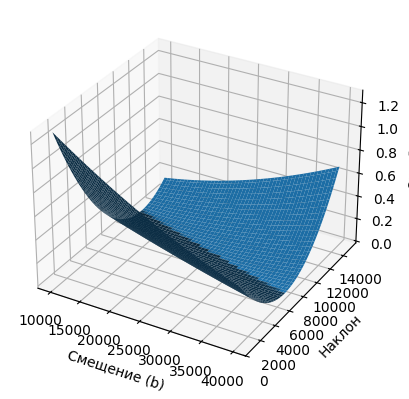

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d') # get current axis

# Наконец, используем метод *plot_surface* объекта
# типа Axes3DSubplot. Также подписываем оси.
surf = ax.plot_surface(w0, w1, Z)
ax.set_xlabel('Смещение (b)')
ax.set_ylabel('Наклон')
ax.set_zlabel('Ошибка')
plt.show()

**[11].** С помощью метода *minimize* из scipy.optimize найдите минимум функции, определенной в п. 6, для значений параметра $w_0$ в диапазоне [10000,35000] и $w_1$ - в диапазоне [2000, 15000].

 Начальная точка – ($w_0$, $w_1$) = (10000, 10000). Используйте метод оптимизации L-BFGS-B (аргумент method метода minimize).

 Проведите на графике из п. 5 Задания 1 прямую, соответствующую найденным оптимальным значениям параметров $w_0$ и $w_1$. Подпишите оси и график. Сделайте легенду, в которой укажите аналитический вид найденной линейной зависимости, коэффициенты округлите до целых значений.

In [ ]:
from scipy.optimize import minimize

In [ ]:
def vec_error(w):
    return error(w[0], w[1])

In [ ]:
res = minimize(vec_error, bounds=((10000, 35000), (2000, 15000)), x0=(10000, 10000), method='L-BFGS-B')

In [ ]:
w0_opt, w1_opt = res.x
w0_opt, w1_opt

(np.float64(24848.344942626227), np.float64(9449.942668339358))

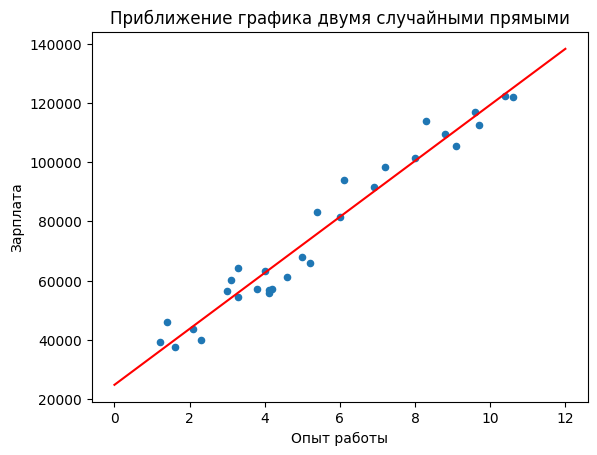

In [ ]:
df.plot(x ='YearsExperience', y ='Salary',kind='scatter', title = "Приближение исходной зависмости функциии, вычисленой через минимизацию фушкции ошибки", xlabel = 'Опыт работы', ylabel = 'Зарплата');
x = np.linspace(0, 12)
y_opt = w0_opt + w1_opt * x
plt.plot(x,y_opt,'r')
plt.show()

**[12].** Примените метод *LinearRegression* из библиотеки sklearn чтобы решить ту же самую задачу минимизации методом наименьших квадратов. [Документация](https://scikit-learn.ru/stable/modules/linear_model.html#ordinary-least-squares-ols) с примером использования метода *LinearRegression*.

Выведите аналитичекий вид полученной линейной зависимости, округлив коэффициенты до целого числа. Сравните с ранее полученными результатами.


In [ ]:
# ваш код здесь

In [ ]:
# ваш код здесь